In [14]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

In [15]:
# TODO: change name if needed
name = "Mrk421"
blazar_coord = SkyCoord.from_name(name)
# TODO: change data_folder if needed
data_folder = "../cta_dc_data/mrk_421/"
data_folder_40deg = data_folder+"40deg/"
data_folder_20deg = data_folder+"20deg/"
irf_file_40deg = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"
irf_file_20deg = "../cta_dc_data/irfs/Prod5-North-20deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [16]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus_40deg = []
hbus_20deg = []
for filename in os.listdir(data_folder_40deg):
    hbus_40deg.append(fits.open(data_folder_40deg + filename))
for filename in os.listdir(data_folder_20deg):
    hbus_20deg.append(fits.open(data_folder_20deg + filename))
    
irf_40deg = load_irf_dict_from_file(irf_file_40deg)
irf_20deg = load_irf_dict_from_file(irf_file_20deg)
print(f"Pointings 40deg: {len(hbus_40deg)}")
print(f"Pointings 20deg: {len(hbus_20deg)}")

Pointings 40deg: 81
Pointings 20deg: 37


In [17]:
e_bins=np.logspace(np.log10(0.05), np.log10(50), 16)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,0.16,17)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [21]:
def collect_data(hbus):
    cts_s = np.zeros((len(e), len(th2)))
    cts_b = np.zeros((len(e), len(th2)))
    t_expo = 0

    for hbu in hbus:
        data_raw = hbu["EVENTS"].data
    
        t = data_raw["TIME"]
        t = np.sort(t)
        t_expo += t[-1] - t[0]
    
        coord = SkyCoord(
            ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
        )
    
        pointing_coord = SkyCoord(
            ra=hbu[1].header["RA_PNT"] * u.deg,
            dec=hbu[1].header["DEC_PNT"] * u.deg,
            frame="icrs",
        )
    
        bkg_center = SkyCoord(
            l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
            b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
            frame="galactic",
        )
        
        seps = coord.separation(blazar_coord).degree
        seps_b = coord.separation(bkg_center).degree
        src_pos_mask = seps < bkg_subtraction_radius
        bkg_pos_mask = seps_b < bkg_subtraction_radius
    
        energ = data_raw["ENERGY"]
    
        for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
            m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
            m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask
    
            h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
            h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
            
            cts_s[i] += h_s
            cts_b[i] += h_b
    return cts_s, cts_b, t_expo

In [22]:
bkg_subtraction_radius = 0.4

cts_s_40deg, cts_b_40deg, t_expo_40deg = collect_data(hbus_40deg)
cts_s_20deg, cts_b_20deg, t_expo_20deg = collect_data(hbus_20deg)

print(f"Exposure time 40deg = {t_expo_40deg/60/60:.1f}h")
print(f"Exposure time 20deg = {t_expo_20deg/60/60:.1f}h")

Exposure time 40deg = 11.3h
Exposure time 20deg = 4.9h


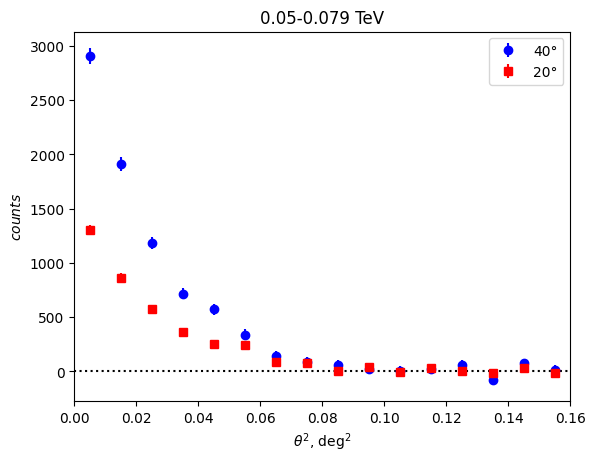

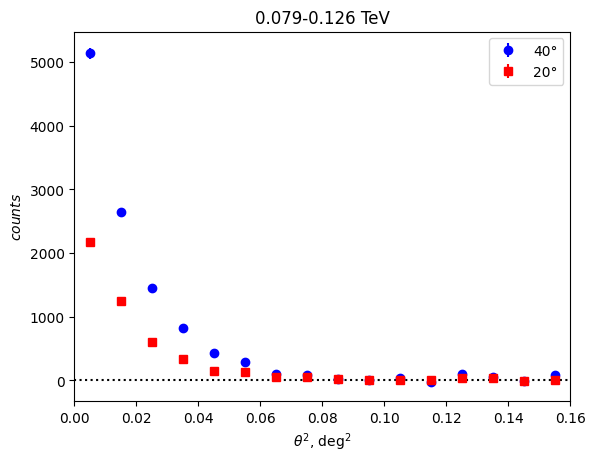

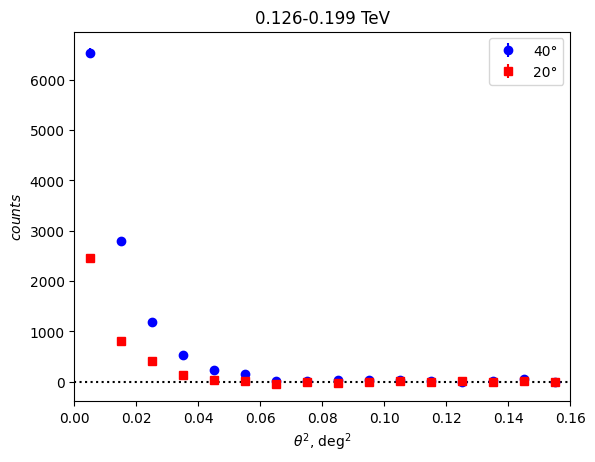

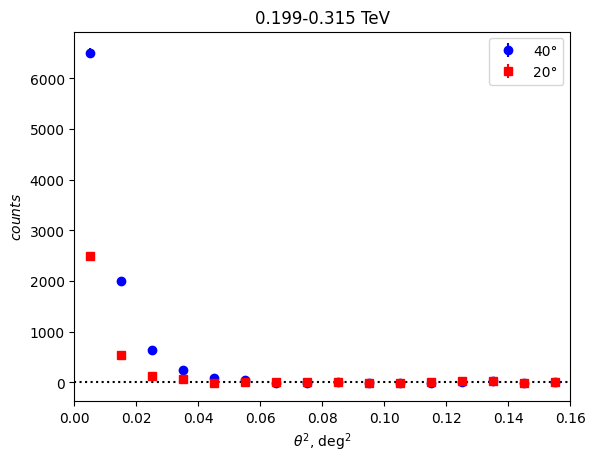

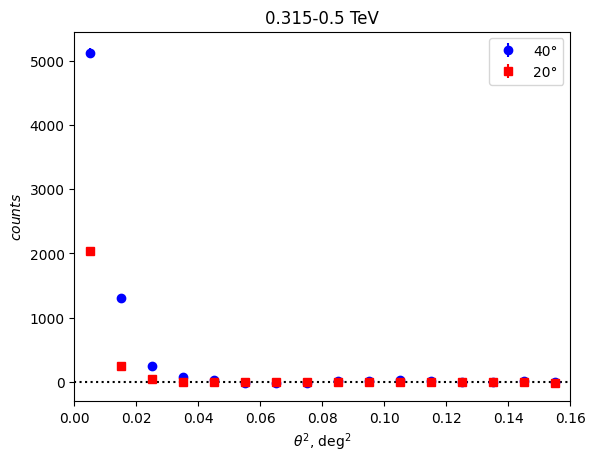

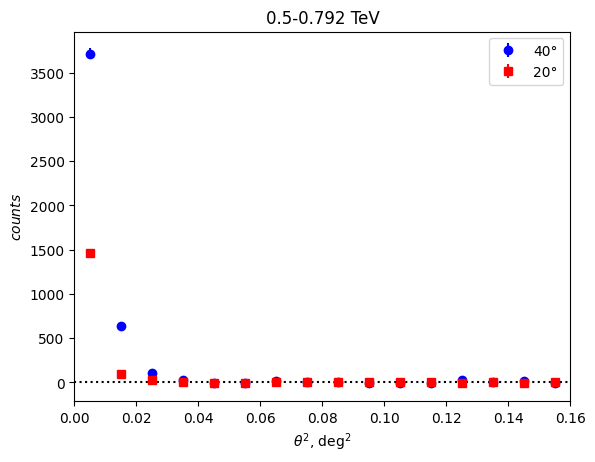

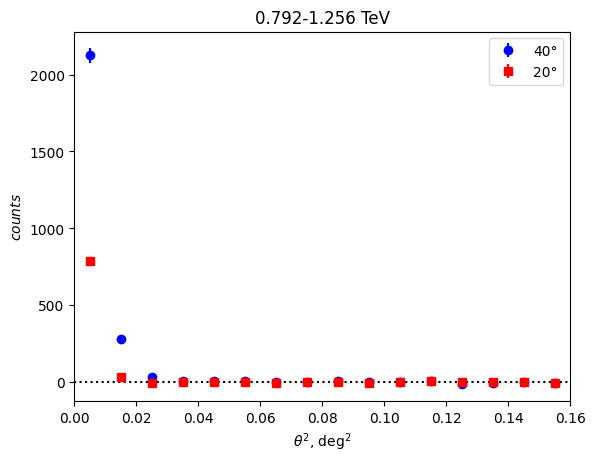

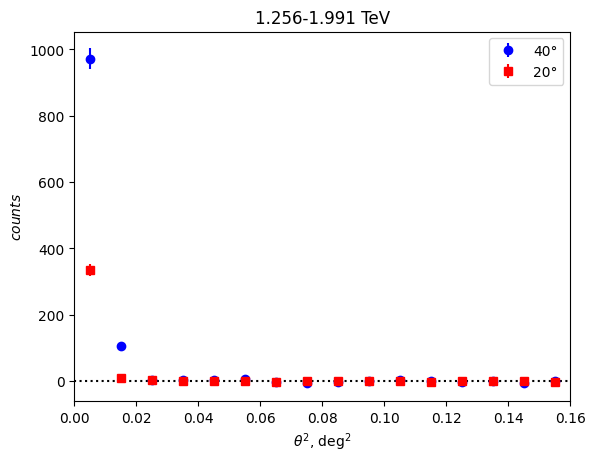

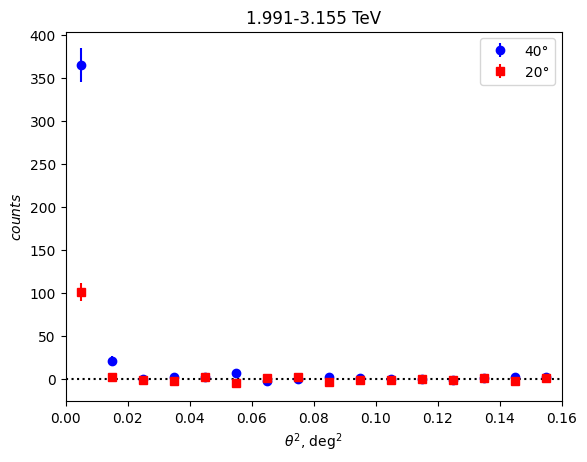

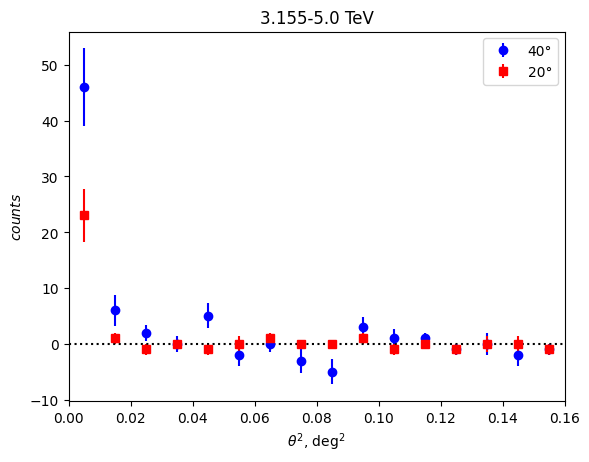

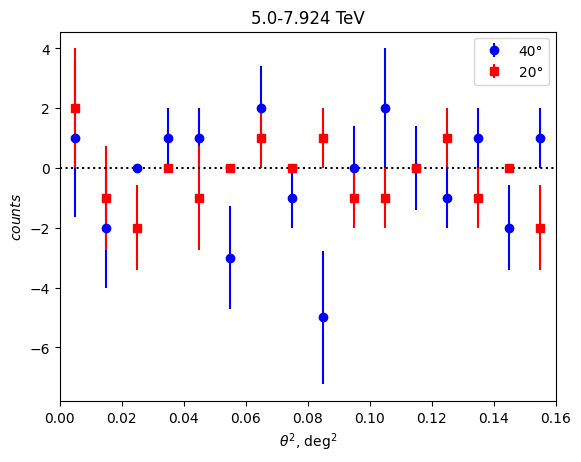

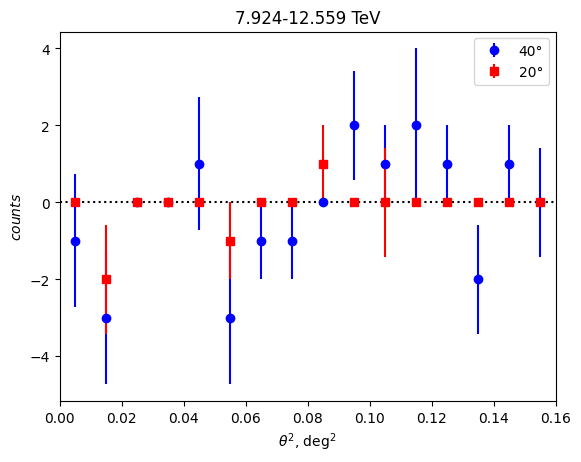

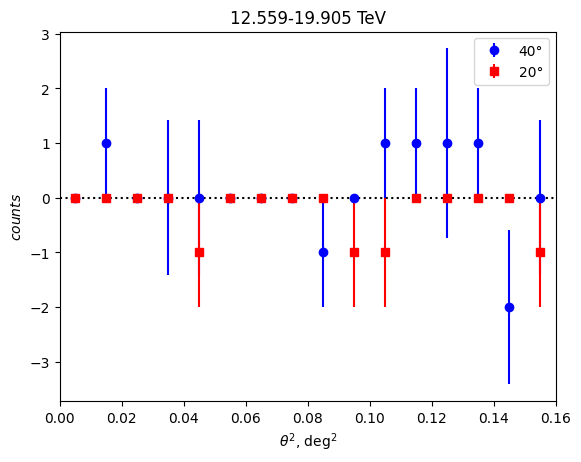

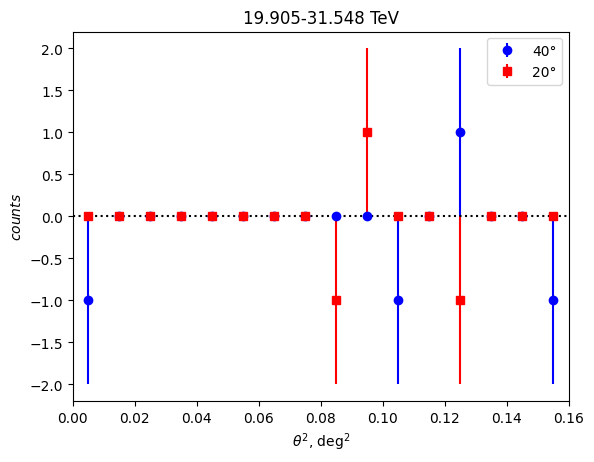

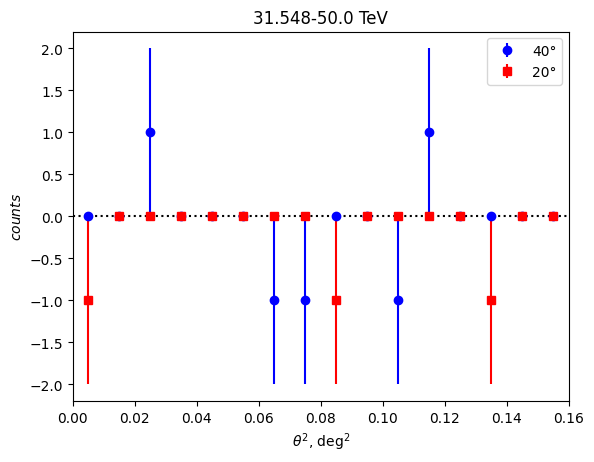

In [24]:
cts_40deg = cts_s_40deg - cts_b_40deg
cts_err_40deg = np.sqrt(cts_s_40deg + cts_b_40deg)

cts_20deg = cts_s_20deg - cts_b_20deg
cts_err_20deg = np.sqrt(cts_s_20deg + cts_b_20deg)

for i, ((cts_40, cts_err_40), (cts_20, cts_err_20)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
    plt.figure()
    plt.errorbar(th2, cts_40, cts_err_40, fmt='o', label='40°', color='blue')
    plt.errorbar(th2, cts_20, cts_err_20, fmt='s', label='20°', color='red')
    plt.axhline(0, color='black', linestyle='dotted')
    plt.xlim(0, 0.16)
    plt.title(str(round(e_mins[i],3)) + '-' + str(round(e_maxs[i],3)) + ' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.legend()
    plt.show()

In [26]:
psf_hbu_40deg = irf_40deg["psf"]
psf_hbu_20deg = irf_20deg["psf"]

print(psf_hbu_40deg)
print(psf_hbu_40deg.info())
print(psf_hbu_40deg.data.shape)
# here i'm guessing the energy bins of the psf since idk how to see them.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
psf_e_means = np.sqrt(psf_e_bins[1:]*psf_e_bins[:-1])
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.058 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.093 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.040 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.065 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

In [27]:
sigmas_ext = [0.1, 0.2, 0.3, 0.4]

In [43]:
def calculate_UL(cts, cts_err, psf_hbu):
    flux_ratios = np.zeros((len(sigmas_ext), len(e)))
    
    for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]
    
        # Normalization of the PSF model to fit best the blazar
        def psf_model(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1**2))
            gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
            gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
            return (gauss1+gauss2+gauss3)

        # rescaling the psf component to match total counts of the data
        psf_component = psf_model(th2)
        psf_component = sum(ct)*psf_component/sum(psf_component)
        # The errors on the counts are independent, here I used this formula for error propagation:
        # z = \sum x_i, then z_err = sqrt(\sum x_i_err**2)
        psf_component_err = np.sqrt(sum(ct_err**2))*psf_component/sum(psf_component) # THIS ERROR EXISTS IN THE FIRST PLACE???
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
    
        # taken from andrii notebook, to fit with psf better:
        step=1.01
        chi2_noext_best=1e10
        adjust=1
        while(chi2_noext<chi2_noext_best):
            chi2_noext_best=chi2_noext
            
            chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(step*adjust*psf_component_err)**2))
            chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
            chisq_vec=np.array([chisq0,chisq1])
            chi2_noext=min(chisq_vec)
            ind=np.argmin(chisq_vec)
            
            if(chi2_noext<chi2_noext_best):
                if(ind==0):
                    adjust*=step
                if(ind==1):
                    adjust/=step
                    
        psf_component *= adjust
        psf_component_err *= adjust
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
        
        fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        fig.subplots_adjust(hspace=0)
        axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
        axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
        axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
        axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
        axs[1].axhline(0,color='black',linestyle='dashed')
    
        # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
        # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
        # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
        for k, sigma_ext in enumerate(sigmas_ext):
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return gauss1_conv + gauss2_conv + gauss3_conv
        
            ct_ext = ext_model(th2)
            ct_ext = sum(ct)*ct_ext/sum(ct_ext)
            ct_ext_plus_src = ct_ext+psf_component
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))

            # Finding the best fit for psf*(extended + point)
            step=1.01
            chi2_ext_best = 1e10
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best):
                chi2_ext_best = chi2_ext
                #ct_ext_err*=adjust_ext for the moment without error
                
                chisq0=sum((ct-step*adjust_point*psf_component-adjust_ext*ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                chisq1=sum((ct-adjust_point*psf_component/step-adjust_ext*ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                chisq2=sum((ct-adjust_point*psf_component-step*adjust_ext*ct_ext)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq3=sum((ct-adjust_point*psf_component-adjust_ext*ct_ext/step)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq_vec=np.array([chisq0,chisq1,chisq2,chisq3])
                chi2_ext=min(chisq_vec)
                ind=np.argmin(chisq_vec)
                
                if(chi2_ext<chi2_ext_best):
                    if(ind==0):
                        adjust_point*=step
                    if(ind==1):
                        adjust_point/=step
                    if(ind==2):
                        adjust_ext*=step
                    if(ind==3):
                        adjust_ext/=step

            ct_ext*=adjust_ext
            psf_component*=adjust_point
            psf_component_err*=adjust_point
            
            ct_ext_plus_src = ct_ext+psf_component
            cts_tot_best = np.sum(ct_ext_plus_src)
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))
            chi2_ext_best = chi2_ext
            ct_ext_best = ct_ext
            print(f"Best fit extended plus point gives chi2: {chi2_ext}")

            # Upper limits
            step=1.01
            chi2_ext_best = chi2_ext
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best + 2.71):
                adjust_ext *= step
                ct_ext = ct_ext_best*adjust_ext
                chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 / (ct_err**2 + psf_component_err**2)))

                chi2_ext_best_fixed_ext = 1e10
                while(chi2_ext < chi2_ext_best_fixed_ext):
                    chi2_ext_best_fixed_ext = chi2_ext
                    
                    chisq0=sum((ct-step*adjust_point*psf_component-ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                    chisq1=sum((ct-adjust_point*psf_component/step-ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                    chisq_vec=np.array([chisq0,chisq1])
                    chi2_ext=min(chisq_vec)
                    ind=np.argmin(chisq_vec)
                    
                    if(chi2_ext<chi2_ext_best_fixed_ext):
                        if(ind==0):
                            adjust_point*=step
                        if(ind==1):
                            adjust_point/=step

            flux_ratio = np.sum(ct_ext)/cts_tot_best
            flux_ratios[k][i] = flux_ratio
            axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
            
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0].set_ylabel('Counts')
        axs[0].legend()
        axs[0].set_yscale('log')
        plt.show()
    return flux_ratios

Best fit extended plus point gives chi2: 76.25017693245587
Best fit extended plus point gives chi2: 37.11929287438282
Best fit extended plus point gives chi2: 32.02263939524878
Best fit extended plus point gives chi2: 28.730494509859803


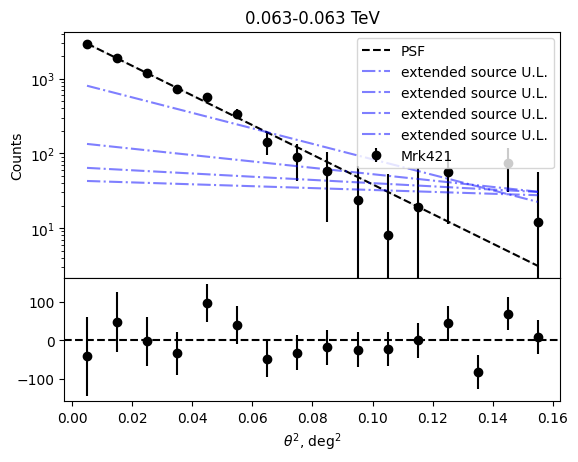

Best fit extended plus point gives chi2: 199.13367922689088
Best fit extended plus point gives chi2: 36.075945860204016
Best fit extended plus point gives chi2: 37.21945455660738
Best fit extended plus point gives chi2: 31.700313488713466


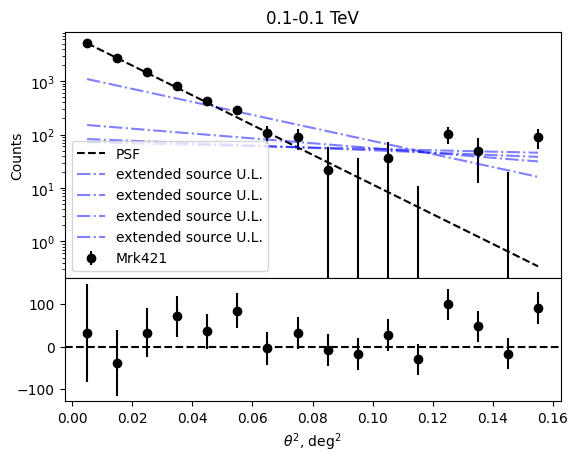

Best fit extended plus point gives chi2: 231.46414734830782
Best fit extended plus point gives chi2: 10.66234947178166
Best fit extended plus point gives chi2: 24.957523541571405
Best fit extended plus point gives chi2: 8.914024645735932


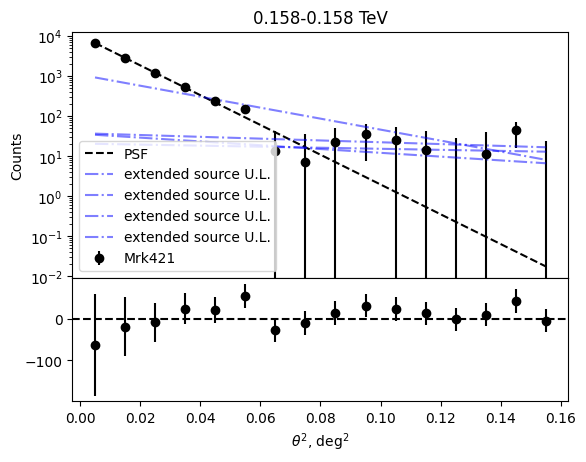

Best fit extended plus point gives chi2: 185.10530718595493
Best fit extended plus point gives chi2: 19.904475603594552
Best fit extended plus point gives chi2: 15.877461627165909
Best fit extended plus point gives chi2: 21.724482692457066


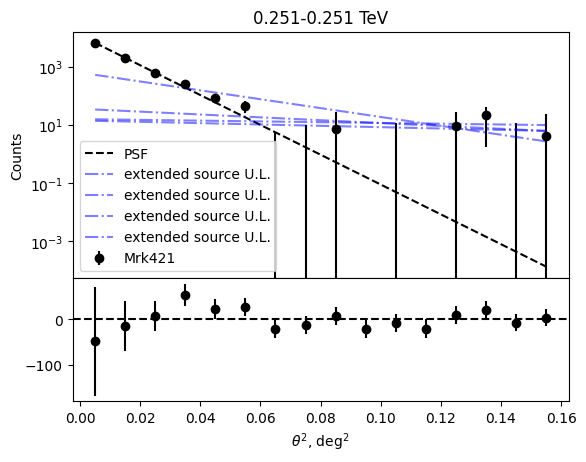

Best fit extended plus point gives chi2: 131.74784697572008
Best fit extended plus point gives chi2: 89.6086032449505
Best fit extended plus point gives chi2: 101.1075687327058
Best fit extended plus point gives chi2: 82.07215028387762


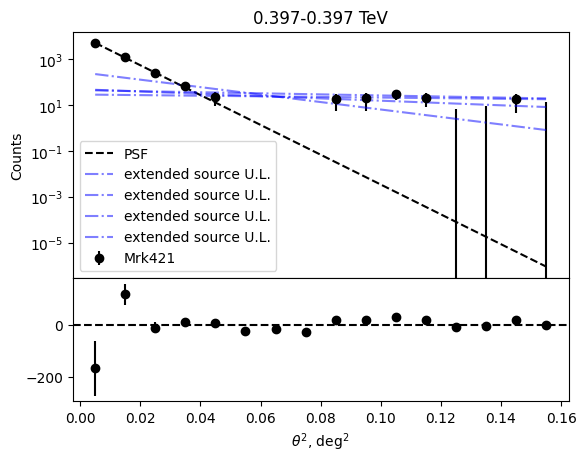

Best fit extended plus point gives chi2: 32.24521324976809
Best fit extended plus point gives chi2: 26.17813196879323
Best fit extended plus point gives chi2: 26.49058489345203
Best fit extended plus point gives chi2: 24.68209662949236


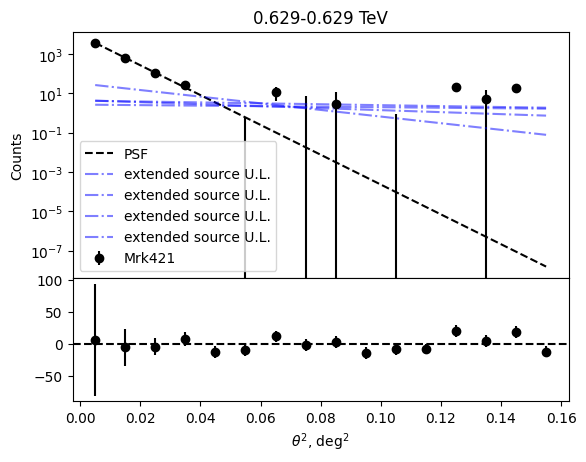

Best fit extended plus point gives chi2: 14.18027668418761
Best fit extended plus point gives chi2: 20.86601416809735
Best fit extended plus point gives chi2: 16.20861878156895
Best fit extended plus point gives chi2: 30.012518278474918


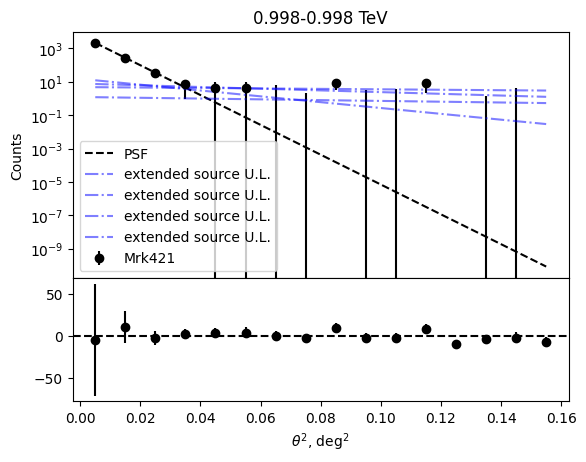

Best fit extended plus point gives chi2: 12.844382605377096
Best fit extended plus point gives chi2: 17.70542584069215
Best fit extended plus point gives chi2: 20.029920931514496
Best fit extended plus point gives chi2: 21.309968466676143


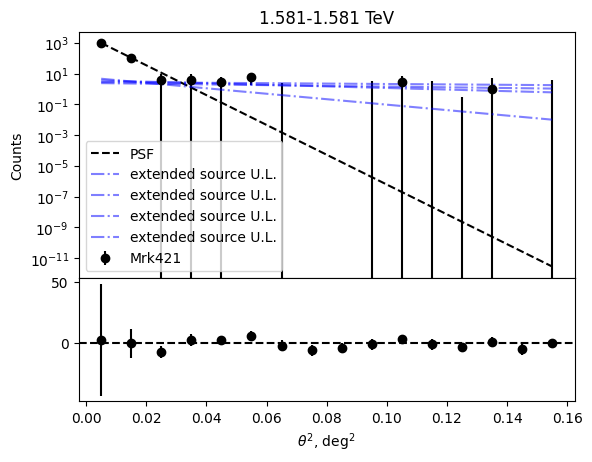

Best fit extended plus point gives chi2: 17.464305730696275
Best fit extended plus point gives chi2: 17.489016962767785
Best fit extended plus point gives chi2: 17.657526453050593
Best fit extended plus point gives chi2: 21.449189663020952


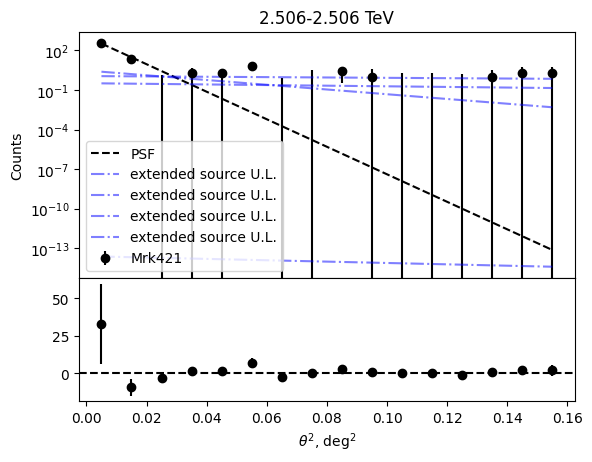

Best fit extended plus point gives chi2: 20.325332625444098
Best fit extended plus point gives chi2: 21.692580791716054
Best fit extended plus point gives chi2: 22.13575615226321
Best fit extended plus point gives chi2: 22.379854198052527


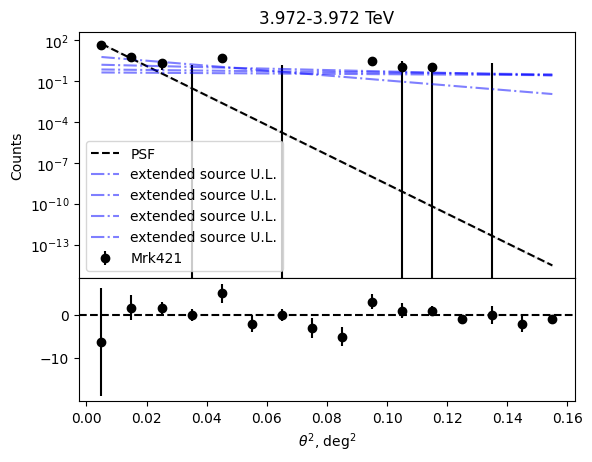

Best fit extended plus point gives chi2: 20.426721127250637
Best fit extended plus point gives chi2: 20.45542035677944
Best fit extended plus point gives chi2: 20.46036838333181
Best fit extended plus point gives chi2: 20.483386376963296


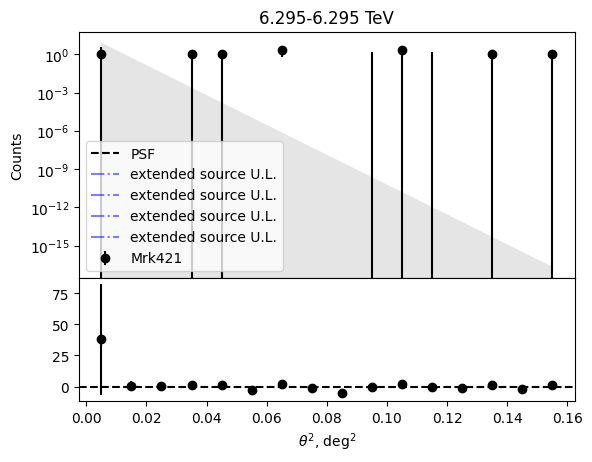

Best fit extended plus point gives chi2: 654164625953454.1
Best fit extended plus point gives chi2: 1.3742365544935842e+16
Best fit extended plus point gives chi2: 1.8572544822041364e+16
Best fit extended plus point gives chi2: 1.9845851932245116e+16


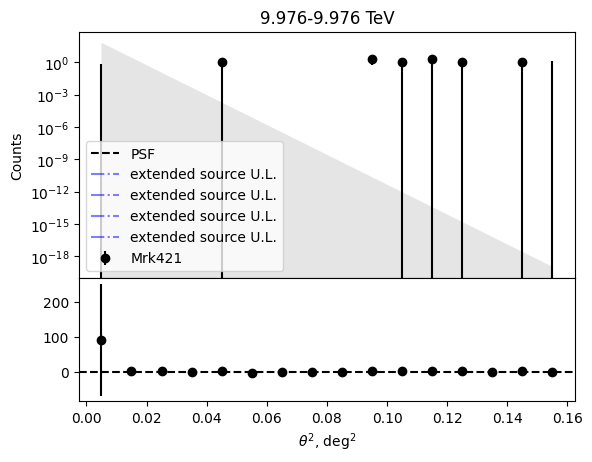

Best fit extended plus point gives chi2: 1.7688818710787086e+23
Best fit extended plus point gives chi2: 8.194033808990184e+24
Best fit extended plus point gives chi2: 1.2707201667288067e+25
Best fit extended plus point gives chi2: 1.4246802859986666e+25


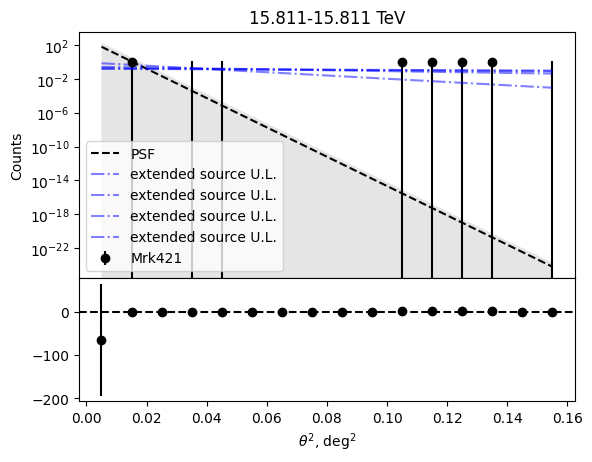

Best fit extended plus point gives chi2: 1.2604135204564483e+50
Best fit extended plus point gives chi2: 1.7175596464751244e+53
Best fit extended plus point gives chi2: 5.211220692597355e+53
Best fit extended plus point gives chi2: 7.419230982736437e+53


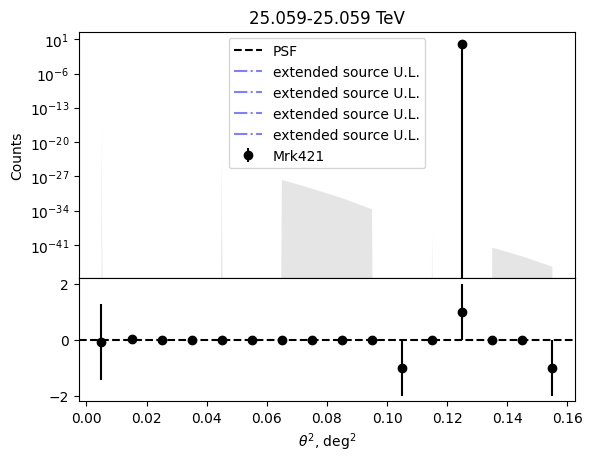

Best fit extended plus point gives chi2: 5.650783887280952e+90
Best fit extended plus point gives chi2: 1.9488598815434133e+94
Best fit extended plus point gives chi2: 6.843873397660652e+94
Best fit extended plus point gives chi2: 1.0239079368395613e+95


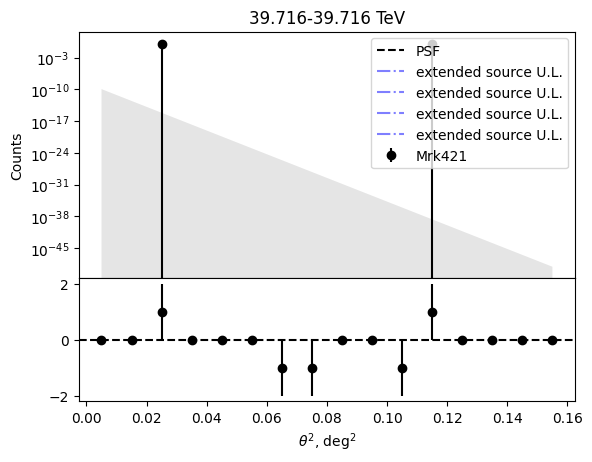

Best fit extended plus point gives chi2: 58.34889818305831
Best fit extended plus point gives chi2: 28.61099731192315
Best fit extended plus point gives chi2: 25.907411881085146
Best fit extended plus point gives chi2: 22.236874309695082


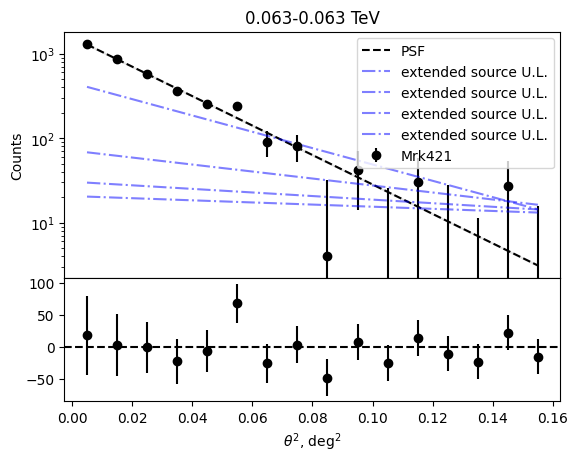

Best fit extended plus point gives chi2: 91.64984432152713
Best fit extended plus point gives chi2: 20.822260301221448
Best fit extended plus point gives chi2: 19.184187062730864
Best fit extended plus point gives chi2: 21.04724317034079


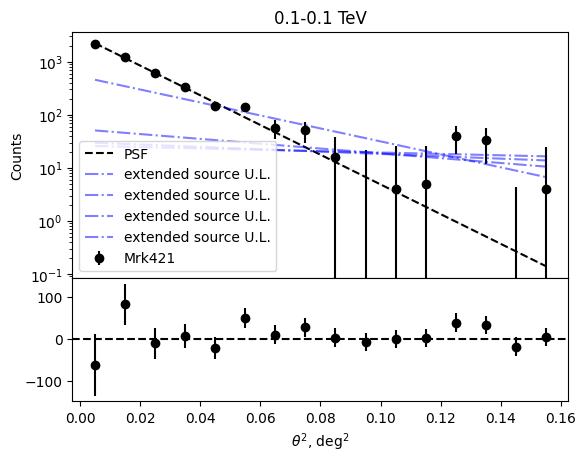

Best fit extended plus point gives chi2: 111.07201304906553
Best fit extended plus point gives chi2: 28.86682882716481
Best fit extended plus point gives chi2: 30.864985039073254
Best fit extended plus point gives chi2: 40.70386311191379


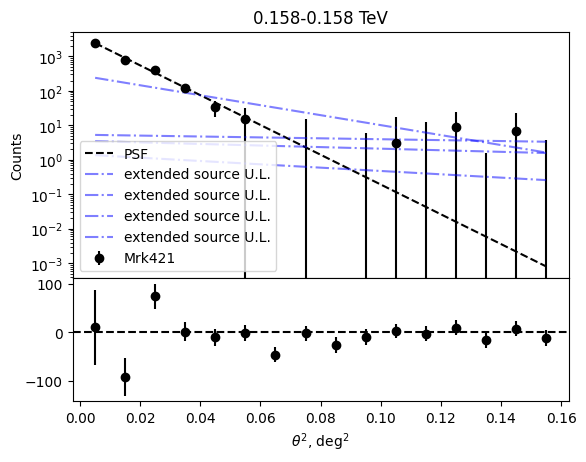

Best fit extended plus point gives chi2: 65.86906521433518
Best fit extended plus point gives chi2: 52.26423369456669
Best fit extended plus point gives chi2: 44.79074157256698
Best fit extended plus point gives chi2: 48.169337070406684


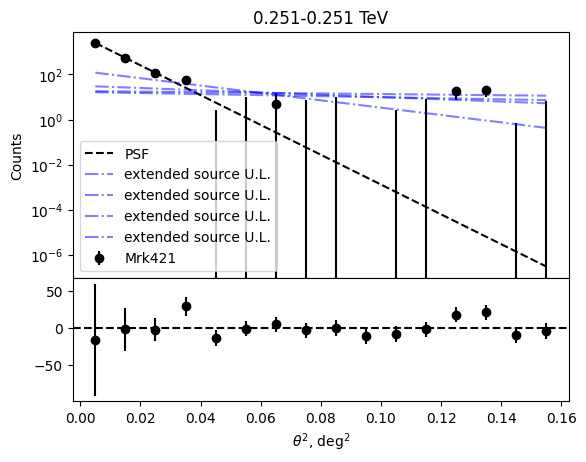

Best fit extended plus point gives chi2: 15.077171087363057
Best fit extended plus point gives chi2: 20.92448779125531
Best fit extended plus point gives chi2: 21.918302793796865
Best fit extended plus point gives chi2: 24.225246415896084


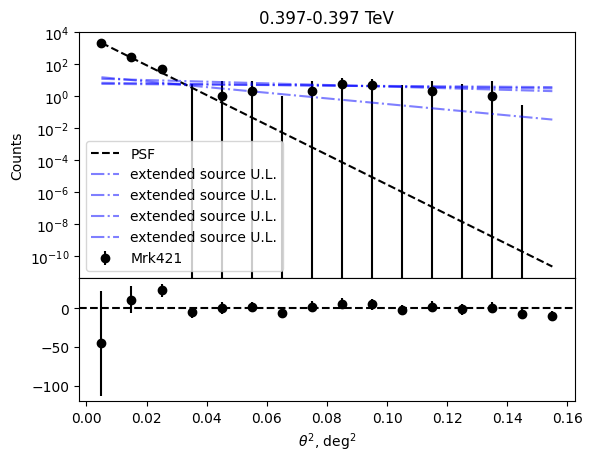

Best fit extended plus point gives chi2: 18.55913951439644
Best fit extended plus point gives chi2: 21.715029181807253
Best fit extended plus point gives chi2: 22.411003524673816
Best fit extended plus point gives chi2: 22.888984867527853


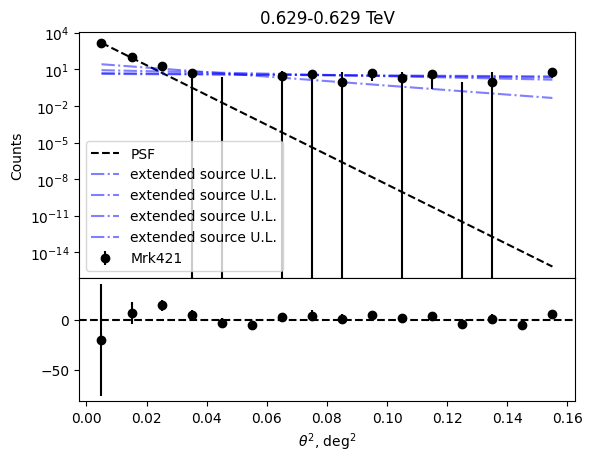

Best fit extended plus point gives chi2: 13.34772571547952
Best fit extended plus point gives chi2: 14.21731705449556
Best fit extended plus point gives chi2: 21.692099787665594
Best fit extended plus point gives chi2: 25.515985224343794


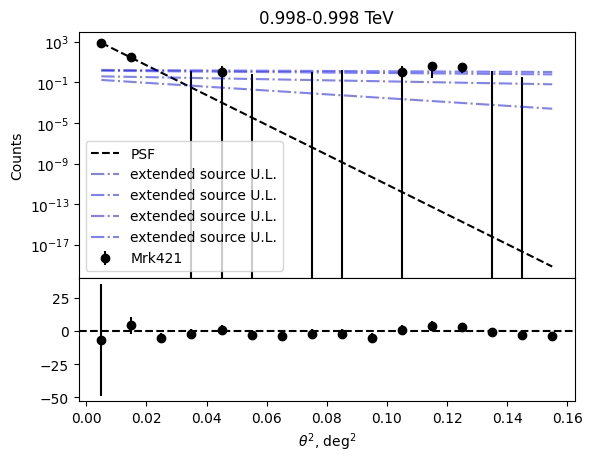

Best fit extended plus point gives chi2: 5.865151954306755
Best fit extended plus point gives chi2: 8.11625599550378
Best fit extended plus point gives chi2: 8.50305798705994
Best fit extended plus point gives chi2: 9.869916549771888


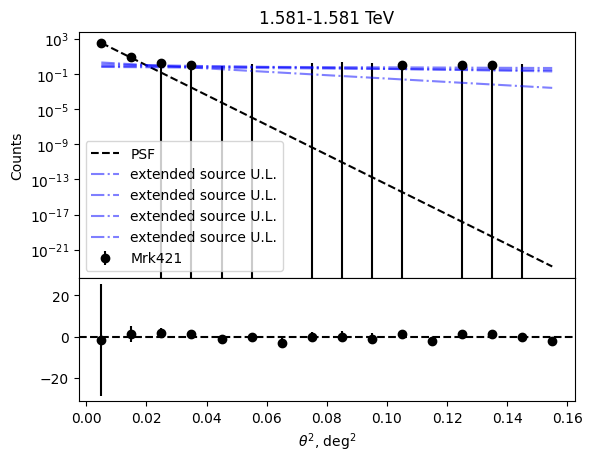

Best fit extended plus point gives chi2: 1.7720446965463922e+38
Best fit extended plus point gives chi2: 3.2187382491358004e+40
Best fit extended plus point gives chi2: 6.530542400639089e+40
Best fit extended plus point gives chi2: 8.05600233992555e+40


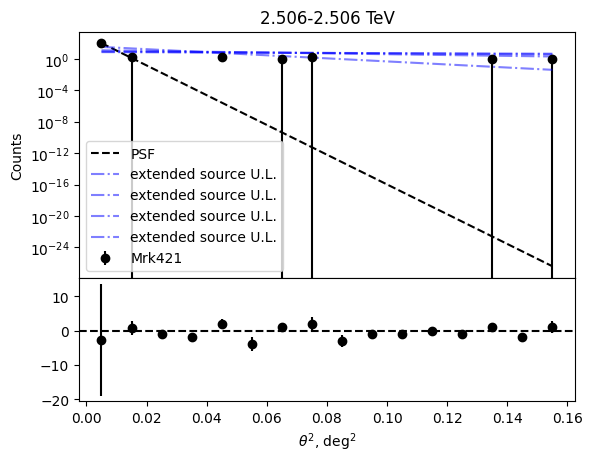

Best fit extended plus point gives chi2: 9.18823742955506e+39
Best fit extended plus point gives chi2: 1.7490365645881445e+42
Best fit extended plus point gives chi2: 3.555524245754235e+42
Best fit extended plus point gives chi2: 4.387206359377716e+42


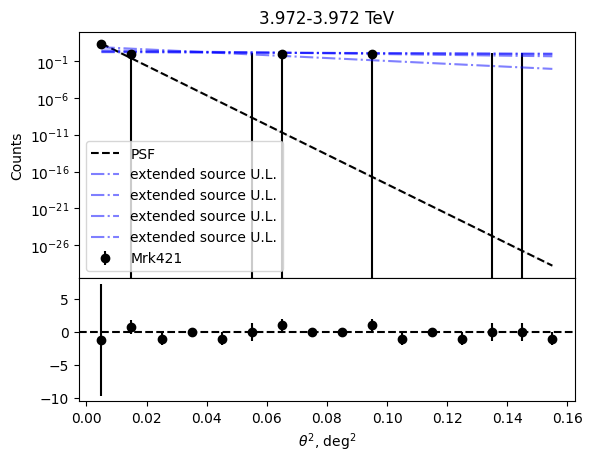

Best fit extended plus point gives chi2: 8.806162237045977e+54
Best fit extended plus point gives chi2: 1.396048713407147e+58
Best fit extended plus point gives chi2: 4.2652253296967103e+58
Best fit extended plus point gives chi2: 6.078652248077935e+58


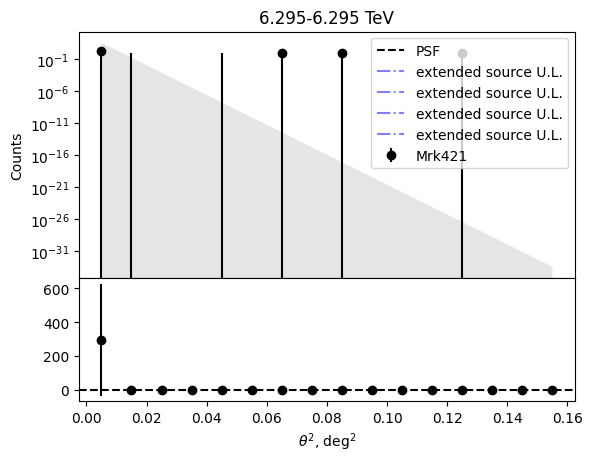

Best fit extended plus point gives chi2: 5.28481699280241e+76
Best fit extended plus point gives chi2: 2.053625719059664e+80
Best fit extended plus point gives chi2: 7.250969986733962e+80
Best fit extended plus point gives chi2: 1.0856892313826816e+81


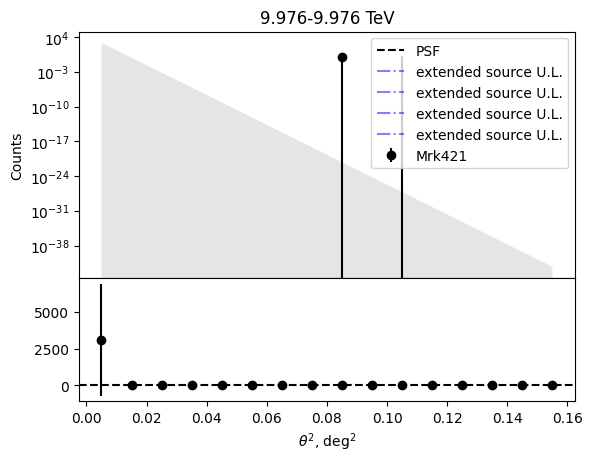

Best fit extended plus point gives chi2: 2.5375560336459644e+104
Best fit extended plus point gives chi2: 5.924933830290337e+107
Best fit extended plus point gives chi2: 1.8413046237903898e+108
Best fit extended plus point gives chi2: 2.6307101513655436e+108


/tmp/ipykernel_900/3205248027.py:145: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[0].set_yscale('log')


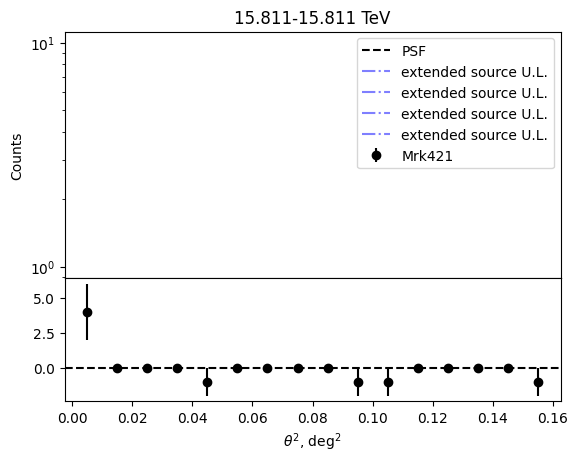

Best fit extended plus point gives chi2: 1.9030794468708914e+138
Best fit extended plus point gives chi2: 1.0099285330792077e+142
Best fit extended plus point gives chi2: 3.615244048050259e+142
Best fit extended plus point gives chi2: 5.424136619790044e+142


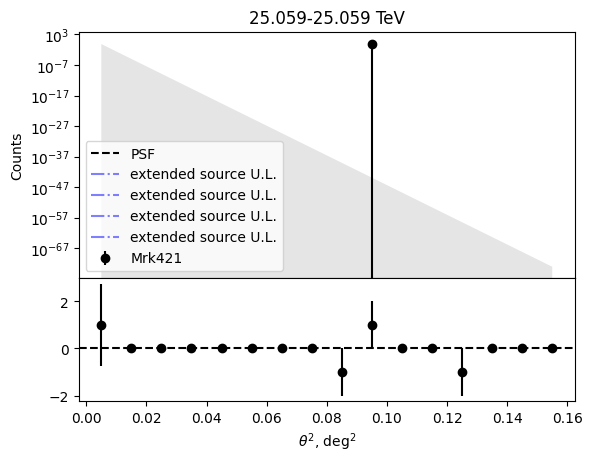

Best fit extended plus point gives chi2: 1.9650858933319534e+179
Best fit extended plus point gives chi2: 1.1653208632788258e+183
Best fit extended plus point gives chi2: 4.1914306499446264e+183
Best fit extended plus point gives chi2: 6.2930274699966965e+183


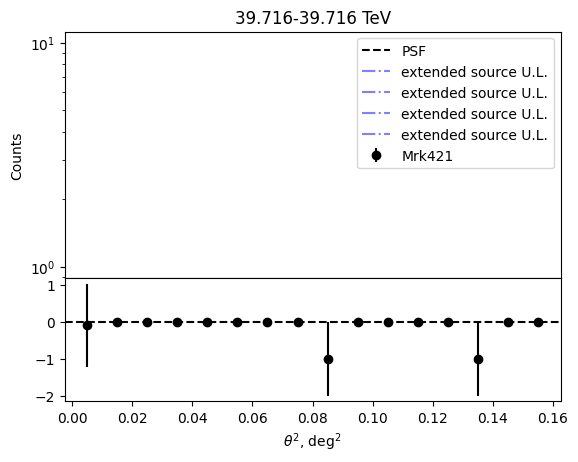

In [44]:
flux_ratios_40deg = calculate_UL(cts_40deg, cts_err_40deg, psf_hbu_40deg)
flux_ratios_20deg = calculate_UL(cts_20deg, cts_err_20deg, psf_hbu_20deg)

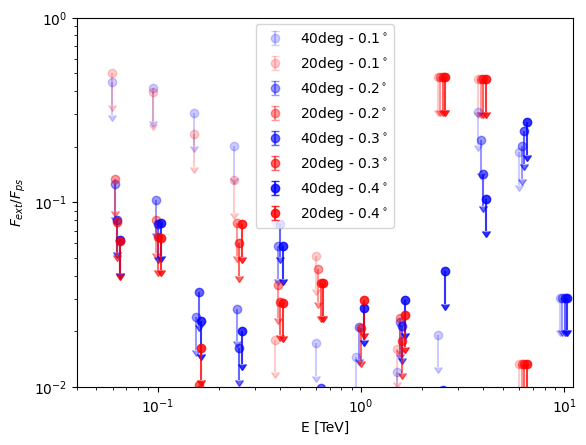

In [46]:
for i, (flux_ratio_40deg, flux_ratio_20deg) in enumerate(zip(flux_ratios_40deg, flux_ratios_20deg)):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_40deg,flux_ratio_40deg/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='blue')
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_20deg,flux_ratio_20deg/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="20deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='red')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01,1)
plt.legend()